<a href="https://colab.research.google.com/github/Chockalingam-M/Deep-Learning-for-Computer_Vision/blob/main/Assignment_HODL_SP24_HW_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 15.777 Homework 1 (Spring 2024): Convolutional Neural Networks


In [3]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics # will perform the evaluating Model, such as accuracy,precision and even confusion matrix
import seaborn as sns #Which bascially run top of the matlab to provide a high level Visuvalisation.

# initialize the seeds of different random number generators so that the
# results will be the same every time the notebook is run
keras.utils.set_random_seed(42)

*italicized text*<font color='red'> **Please be sure to make a copy of this notebook in your own Google Drive so that your work is saved!** </font>

# Introduction

Your goal in this exercise is to detect emotion from a facial image. To that end, we will use the 2013 Facial Expression Recognition (FER) dataset.

The dataset consists of ~36,000 images, each annotated with one of seven labels:
* angry
* disgust
* fear
* happy
* sad
* surprise
* neutral

The goal of this homework assignment is to walk you through how to:

1. Build a Convolutional Neural Network (CNN) *from scratch* to detect emotion in facial images (Problems 1 and 2)
2. Use data augmentation to increase the size of your training data (Problem 3)
3. Use transfer learning to customize a pretrained model to solve the same problem (Problem 4)

But first, let's get the data.

In [4]:
!wget -q -O fer2013.csv -P ./ https://dl.dropbox.com/scl/fi/e2ik6aryemboameq1rwwn/fer2013.csv?rlkey=ux7tyge6flk9nnuul9desizgf&dl=0

The data has 35887 rows and 3 columns:
* Emotion - encoded as the numbers 0 (anger) through 6 (neutral)
* Pixels - A space-separated list of numbers representing the pixels of this image.
* Usage - No need to worry about this column

In [5]:
data = pd.read_csv('fer2013.csv')
data

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training
...,...,...,...
35882,6,50 36 17 22 23 29 33 39 34 37 37 37 39 43 48 5...,PrivateTest
35883,3,178 174 172 173 181 188 191 194 196 199 200 20...,PrivateTest
35884,0,17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...,PrivateTest
35885,3,30 28 28 29 31 30 42 68 79 81 77 67 67 71 63 6...,PrivateTest


The pixel values for each image is provided as a space-separated list of numbers. How many pixels in an image?

In [6]:
len(data.loc[0, 'pixels'].split(' '))

2304

### Pre-Processing the Pixels (Independent Variable)

Each image is encoded as a list of 2304 pixels. We will reshape this into an 48x48 image next.

Recall that a color image is represented as a tensor of dimension N by M by 3, where the 3 represents the 3 color channels (red, green and blue). Our images from the FER 2013 dataset are grayscale images, with only a single channel representing the amount of black in the image. This is inconvenient to work with because many pre-trained models used in transfer learning, such as the one we will use in Problem 4, require the input image to have 3 channels.

To get around this, we will take each image, a 48 x 48 tensor and transform it into a 48 x 48 x 3 tensor by simply duplicating it three times. We can think of a greyscale image is one where the red, green and blue color channels are exactly the same.

The following code transforms our dataset into a tensor of shape (35887, 48, 48, 3): a list of 35887 images, each of which are a (48, 48, 3)-shape tensor.

In [7]:
pixels = data['pixels'].tolist()
width, height = 48, 48
faces = []
for pixel_sequence in pixels:
    face = [int(pixel) for pixel in pixel_sequence.split(' ')] # read each face as a 1-d array
    face = np.asarray(face).reshape(width, height) # reshape the length 2304 1-d array into an 48x48 array
    face = np.stack((face,)*3, axis=-1)
    faces.append(face.astype('float32'))

faces = np.asarray(faces)
faces.shape

(35887, 48, 48, 3)

For the first image, i.e. `faces[0]`, we can examine its first channel (corresponding to "red").

In [8]:
faces[0, :, :, 0]

array([[ 70.,  80.,  82., ...,  52.,  43.,  41.],
       [ 65.,  61.,  58., ...,  56.,  52.,  44.],
       [ 50.,  43.,  54., ...,  49.,  56.,  47.],
       ...,
       [ 91.,  65.,  42., ...,  72.,  56.,  43.],
       [ 77.,  82.,  79., ..., 105.,  70.,  46.],
       [ 77.,  72.,  84., ..., 106., 109.,  82.]], dtype=float32)

This is the exact same as the second channel (corresponding to "blue"). And similarly for green.

In [9]:
faces[0, :, :, 1]

array([[ 70.,  80.,  82., ...,  52.,  43.,  41.],
       [ 65.,  61.,  58., ...,  56.,  52.,  44.],
       [ 50.,  43.,  54., ...,  49.,  56.,  47.],
       ...,
       [ 91.,  65.,  42., ...,  72.,  56.,  43.],
       [ 77.,  82.,  79., ..., 105.,  70.,  46.],
       [ 77.,  72.,  84., ..., 106., 109.,  82.]], dtype=float32)

### Pre-Processing for Emotions (Dependent Variable)

Next, let's take a look at how emotion (the dependent variable) is encoded. We have that 0 = 'angry', 1 = 'disgust', ... 6 = 'neutral'.

In [10]:
data.emotion.unique()

array([0, 2, 4, 6, 3, 5, 1])

We will convert emotion to a one-hot encoding using the `pd.get_dummies` function.

In [11]:
emotions = pd.get_dummies(data['emotion']).to_numpy() # each emotion is 'one-hot' encoded as a 7-dim vector
emotions_names = ('angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral')
emotions.shape

(35887, 7)

### Example Images
Lets take a look at some of these fun images!

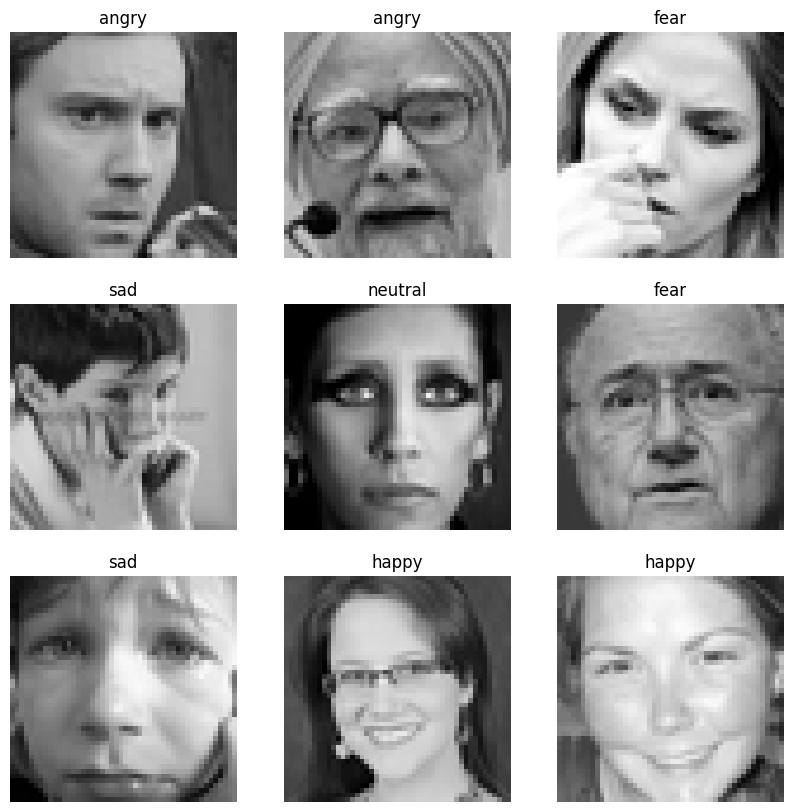

In [12]:
fig = plt.figure(figsize=(10, 10))
for i in range(9):
    ax = fig.add_subplot(3, 3, i+1)
    ax.set_title(f"{emotions_names[np.argmax(emotions[i])]}")
    ax.imshow(faces[i].astype('uint8'))
    ax.axis('off')

### Train/Test Split
As in the original dataset, we will reserve the first 28,709 images for training and the rest for testing.

In [13]:
train_faces, train_emotions =  faces[:28709], emotions[:28709]
test_faces, test_emotions =  faces[28709:], emotions[28709:]

train_faces.shape, train_emotions.shape, test_faces.shape, test_emotions.shape

((28709, 48, 48, 3), (28709, 7), (7178, 48, 48, 3), (7178, 7))

# Problem 1: Base Model [30 Points]
In this problem, we will build a simple CNN with three convolutional blocks, one dense layer and one output layer.



## Part (a): Building the Model [10 points]
We would like to build a CNN with the following model summary. Fill in the code in the cell below so that the output of `model.summary()` matches that of the image above. Be sure to use relu activation for each of the Conv2D layers and the appropriate activation function for the output layer.


![](https://dl.dropbox.com/scl/fi/lrmaupoa243xrrsfj3qiy/cnn_model.PNG?rlkey=n5axqin6vx652qrgduyosg0pc&dl=0)

In [14]:
input = keras.Input(shape=(48, 48, 3), name="input")

###### YOUR CODE HERE #####
h = keras.layers.Rescaling(1./255)(input)
h = keras.layers.Conv2D(16,kernel_size=(2,2), activation='relu')(h)
h = keras.layers.MaxPool2D()(h)
h = keras.layers.Conv2D(16, kernel_size=(2,2),activation='relu')(h)
h = keras.layers.MaxPool2D()(h)
h = keras.layers.Conv2D(16, kernel_size=(2,2),activation='relu')(h)
h = keras.layers.MaxPool2D()(h)

h = keras.layers.Flatten()(h)
dense_1 = keras.layers.Dense(256, activation='relu')(h)
output = keras.layers.Dense(7, activation='softmax')(dense_1)
###### YOUR CODE HERE #####

model = keras.Model(input, output, name='CNN_model')
model.summary()

Model: "CNN_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 47, 47, 16)     │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 22, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       102,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,743 (416.96 KB)

 Trainable params: 106,743 (416.96 KB)

 Non-trainable params: 0 (0.00 B)

## Part (b): Number of Parameters [10 points]
The model above has $106,743$ trainable parameters and is computed by $208 + 1040 + 1040 + 102656 + 1799$. Explain how each of these 5 numbers is calculated and show your computations (e.g. 208 = 16 * 3 * 4 + 16).


<font color='red'>**Your Answer.**</font>



1.   208 = 16*3*4 + 16
2.   1040 = ((4*16)+1)*16
3.   1040 = ((4*16)+1)*16
4.   102656 = (400*256)+256
5.  1799 = (256*7)+7



## Part (c): Training and Evaluation [10 points]

Let us compile our model and fit it on the training data. Since we one-hot-encoded the dependent variable, we use `categorical_crossentropy`, not `sparse_categorical_crossentropy`.

Fill in the parameters of `model.compile` and `model.fit` below.

* Compile the model using the `categorical_crossentropy` loss, `adam` optimizer and report the `accuracy` metric.
* Fit the model on `train_faces`, `train_emotions` using a batch size of 64, for 30 epochs and a validation split of 20%.

In [15]:
model.compile(loss='categorical_crossentropy', optimizer= 'adam',  metrics=['accuracy'])

model_history = model.fit(train_faces, train_emotions, batch_size=64, epochs=30, validation_split=0.2)

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.2950 - loss: 1.7382 - val_accuracy: 0.3656 - val_loss: 1.6505
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3854 - loss: 1.5816 - val_accuracy: 0.4180 - val_loss: 1.5373
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4218 - loss: 1.4952 - val_accuracy: 0.4359 - val_loss: 1.4752
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4479 - loss: 1.4296 - val_accuracy: 0.4533 - val_loss: 1.4246
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4698 - loss: 1.3759 - val_accuracy: 0.4681 - val_loss: 1.3880
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4926 - loss: 1.3300 - val_accuracy: 0.4796 - val_loss: 1.3566
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5114 - loss: 1.2861 - val_accuracy: 0.4911 - val_loss: 1.3371
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5311 - loss: 1.2438 - val_accuracy: 

**Epochs and Batches.**

In your own words, please explain the relationship between an epoch and a batch in stochastic gradient descent.

<font color='red'>Epoch is totally the count of time taken my the model to run complete set of data, from the first layer to last layer for all images.
Like the word batch mean, we group the images into separate batch and run them completely throught the layer and do a back propagation, for error correction. </font>






When we ran `model.fit`, we saw that there are 359 batches per epoch. Please explain how this 359 is calculated. _Hint_: There are 28,709 training data points and 20% is set aside for validation.

<font color='red'>The total data is 28709 is that after taking out for validation remains 22968. We have a batch size of 64 when dividing 22968/64 gives around 359.</font>



**Plotting the Training/Validation Accuracy Curve**

Use the `plot_accuracy` function below to plot the training and validation accuracy across the training epochs.

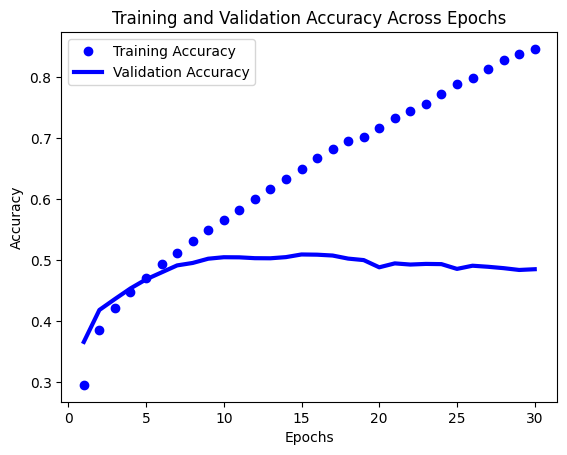

In [18]:
def plot_accuracy(model_history):
    history_dict = model_history.history
    acc = history_dict["accuracy"]
    val_acc = history_dict["val_accuracy"]
    epochs = range(1, len(acc) + 1)
    plt.plot(epochs, acc, "bo", label="Training Accuracy", linewidth=3)
    plt.plot(epochs, val_acc, "b", label="Validation Accuracy", linewidth=3)
    plt.title("Training and Validation Accuracy Across Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_accuracy(model_history)

**Model Accuracy**

Calculate the accuracy on the test set. Write your code below to show the accuracy.

In [19]:
model.evaluate(test_faces, test_emotions)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4717 - loss: 2.3580


[2.3580400943756104, 0.4717191457748413]

# Problem 2: Wider and Deeper Models [30 Points]
In this problem, we will modify the model from Problem 1 in two ways:
* Increase the width of the model by adding more filters and more neurons in the dense layer.
* Increase the depth of the model by adding another dense layer.

### Part (a): Wider Model [5 points]
Take the `model` from Problem 1 and modify it into `wider_model` by using 32 filters for the convolution layers instead of 16.


Write your new code below and verify that `wider_model.summary()` looks correct. Your model should have 215,527 parameters.



In [21]:
input = keras.Input(shape=train_faces.shape[1:])

h = keras.layers.Rescaling(1./255)(input)
h = keras.layers.Conv2D(32,kernel_size=(2,2), activation="relu", name="layer1") (h)
h = keras.layers.MaxPool2D()(h)
h = keras.layers.Conv2D (32,kernel_size=(2,2), activation="relu", name="layer2") (h)
h = keras.layers.MaxPool2D()(h)
h = keras.layers.Conv2D (32,kernel_size=(2,2), activation="relu", name="layer3") (h)
h = keras.layers.MaxPool2D()(h)
h = keras.layers.Flatten ()(h)

h = keras.layers.Dense (256, activation="relu", name="layer")(h)
output = keras.layers.Dense(7, activation ="softmax", name="final_layer")(h)
wider_model = keras.Model(input, output, name='wider_cnn')
wider_model.summary()

Model: "wider_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer1 (Conv2D)                 │ (None, 47, 47, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Conv2D)                 │ (None, 22, 22, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Conv2D)                 │ (None, 10, 10, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer (Dense)                   │ (None, 256)            │       205,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_layer (Dense)             │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,527 (841.90 KB)

 Trainable params: 215,527 (841.90 KB)

 Non-trainable params: 0 (0.00 B)

## Part (b): Number of Parameters [5 points]
The model above has $215,527$ trainable parameters and is computed by $416 + 4128 + 4128 + 205056 + 1799$. Explain how each of these 5 numbers is calculated and show your computations.

<font color='red'> Your answer: </font>

1) 3 channels and 2*2 = 4 which gives 4*3*32 and the bias of 32 gives 416.</br>
2) (2)(2) = 4, which gives ((4*32)+1)*32 = 4128 </br>
3) (2)(2) = 4, which gives ((4*32)+1)*32 = 4128 </br>
4) fllatten (800)*256 + 256 for bias = 205056 </br>
5) (256)(7)+ 7 for bias = 1799

## Part (c): Training and Evaluation [5 points]
Let's train our model and evaluate its performance.

In [22]:
wider_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

wider_model_history = wider_model.fit(train_faces, train_emotions, batch_size=64, epochs=30, validation_split=0.2)

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.3078 - loss: 1.7125 - val_accuracy: 0.4000 - val_loss: 1.5745
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4199 - loss: 1.5064 - val_accuracy: 0.4530 - val_loss: 1.4363
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4694 - loss: 1.3861 - val_accuracy: 0.4829 - val_loss: 1.3566
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5022 - loss: 1.3037 - val_accuracy: 0.5012 - val_loss: 1.3254
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5325 - loss: 1.2345 - val_accuracy: 0.5075 - val_loss: 1.3119
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5590 - loss: 1.1705 - val_accuracy: 0.5247 - val_loss: 1.2754
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5868 - loss: 1.1076 - val_accuracy: 0.5254 - val_loss: 1.2755
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6130 - loss: 1.0457 - val_accuracy: 0

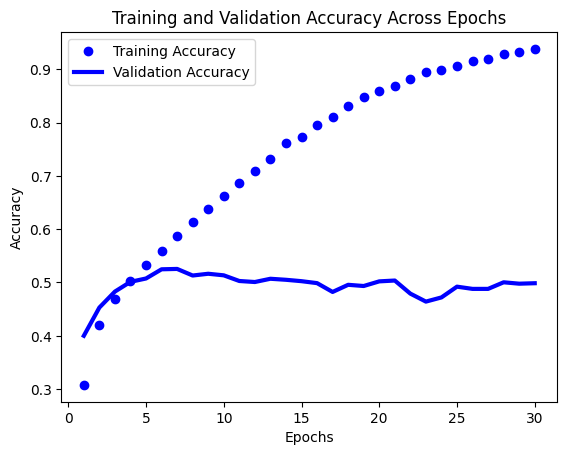

In [23]:
plot_accuracy(wider_model_history)

In [24]:
# Evaluate the model on the test set
wider_model.evaluate(test_faces, test_emotions)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4930 - loss: 3.4347


[3.4346652030944824, 0.4930342733860016]

Compare the accuracy curve of `wider_model` to that of `model` from Problem 1. Which shows more evidence of overfitting after 30 epochs? Does that make sense?

<font color='red'> **Your Answer.** </font>

Wider_model shows more accuracy of overfitting because the train data reach 100% in 30 epoch itself, while normal model goes until 80%, but the thing is both model given same accuracy around 47%. but the parameter is high and overfitting occur.


## Part (d): Deeper Model [5 Points]
Now, build a new model called `deep_model` by taking `model` from Problem 1 and add an additional dense layer of 256 nodes immediately after the original dense layer of 256 nodes. The new model should have a total of 2 dense layers of 256 nodes each and have a total of 172,535 parameters.

Train the model, plot its accuracy vs epochs using the `plot_accuracy` function, and report the model's accuracy on the test set.

In [25]:
input = keras.Input(shape=train_faces.shape[1:])

h = keras.layers.Rescaling(1./255)(input)
h = keras.layers.Conv2D(16, kernel_size=(2,2), activation="relu", name="layer1")(h)
h = keras.layers.MaxPool2D()(h)
h = keras.layers.Conv2D(16, kernel_size=(2,2), activation="relu", name="layer2")(h)
h = keras.layers.MaxPool2D()(h)
h = keras.layers.Conv2D(16, kernel_size=(2,2), activation="relu", name="layer3")(h)
h = keras.layers.MaxPool2D()(h)

h = keras.layers.Flatten()(h)
h = keras.layers.Dense(256, activation="relu", name="layer4")(h)
h = keras.layers.Dense(256, activation="relu", name="layer5")(h)

output = keras.layers.Dense(7, activation="softmax", name="final_layer")(h)

deeper_model = keras.Model(input, output, name='deeper_cnn')
deeper_model.summary()

Model: "deeper_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer1 (Conv2D)                 │ (None, 47, 47, 16)     │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 23, 23, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Conv2D)                 │ (None, 22, 22, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 11, 11, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Conv2D)                 │ (None, 10, 10, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer4 (Dense)                  │ (None, 256)            │       102,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer5 (Dense)                  │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_layer (Dense)             │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172,535 (673.96 KB)

 Trainable params: 172,535 (673.96 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
deeper_model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

deeper_model_history = deeper_model.fit(train_faces, train_emotions, batch_size=64, epochs= 30, validation_split=0.2)

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.3061 - loss: 1.7194 - val_accuracy: 0.3896 - val_loss: 1.5817
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4093 - loss: 1.5239 - val_accuracy: 0.4263 - val_loss: 1.4917
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4489 - loss: 1.4269 - val_accuracy: 0.4620 - val_loss: 1.4169
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4793 - loss: 1.3543 - val_accuracy: 0.4796 - val_loss: 1.3740
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5065 - loss: 1.2897 - val_accuracy: 0.4892 - val_loss: 1.3611
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5333 - loss: 1.2275 - val_accuracy: 0.4948 - val_loss: 1.3549
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5583 - loss: 1.1630 - val_accuracy: 0.4981 - val_loss: 1.3684
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5864 - loss: 1.0981 - val_accuracy: 0

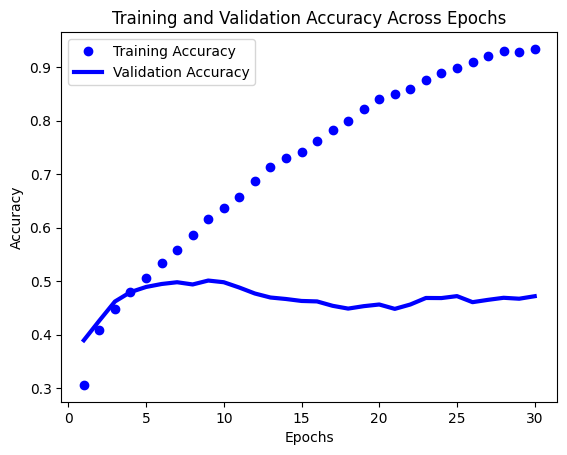

In [27]:
plot_accuracy(deeper_model_history)

In [28]:
deeper_model.evaluate(test_faces, test_emotions)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4646 - loss: 3.9827


[3.982656478881836, 0.4646140933036804]

## Part (e): Comparison [10 points]
Comment on the difference between the test accuracy of `model`, `wider_model` and `deeper_model`. Did widening the model or deepening the model result in a better performance? Why? Do you think
this result generally holds true for all problems?

<font color='red'>**Your Answer**</font>

Test Accuracy Comparison:
* `model`: 46.98%
* `wider_model`: 47.59%
* `deeper_model`: 46.25%

From the number we can see the difference in the test data, for the model with thw wider and more number of neuron has got a higher acuracy, while other two perform slightly less than that. But the parameter is high for the wider model.

# Problem 3: Data Augmentation [15 Points]

The basic idea of augmentation is to alter the image so slightly that the value of the dependent variable (i.e. the category that it belongs to) doesn't change.

Keras allows us to easily perform data augmentation using layers such as:

* `keras.layers.RandomFlip`
* `keras.layers.RandomZoom`
* `keras.layers.RandomRotation`

Lets quickly visualize what the augmentation does ... Here, we flip the images horizontally, then apply a random zoom of up to 20%. Note that you do not need to understand how the code below works. Most of it is there to allow us to visualize the augmentation.

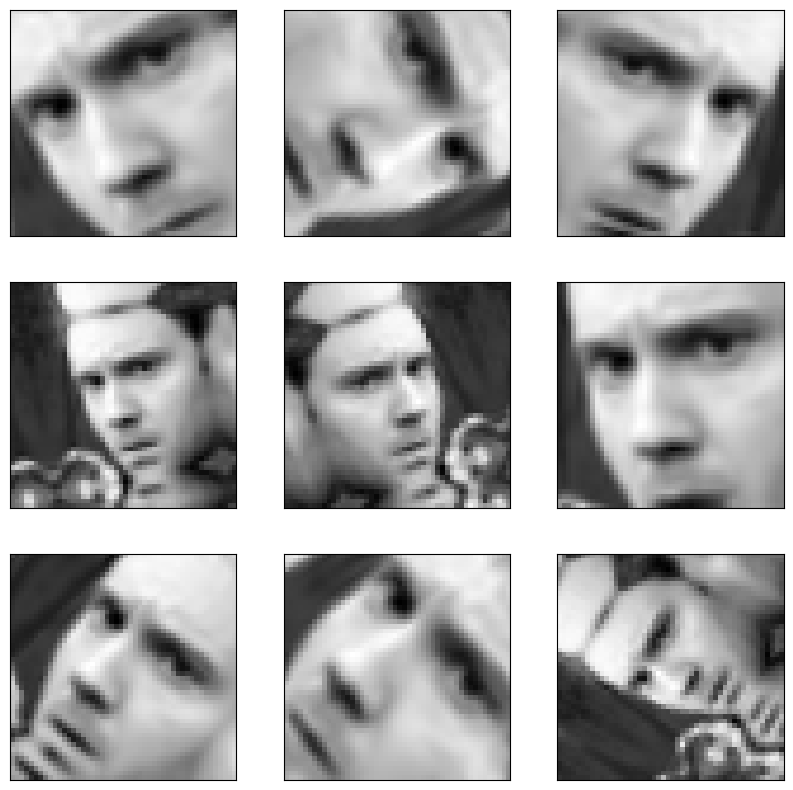

In [30]:
def augment_images(image):
    x = keras.layers.RandomFlip("horizontal")(image)
    x = keras.layers.RandomZoom(0.5)(x)
    x = keras.layers.RandomRotation(0.2)(x)

    return x

augmented_images = [augment_images(np.expand_dims(train_faces[0],axis=0)) for i in range(9)]
fig = plt.figure(figsize=(10, 10))
for i in range(9):
    ax = fig.add_subplot(3, 3, i+1, xticks=[], yticks=[])
    ax.imshow(tf.keras.preprocessing.image.array_to_img(augmented_images[i][0]), cmap='gray', vmin=0, vmax=255)

We take our model `wider_model` from Problem 2(c) and add a random flip and random zoom as **layers** before the rescaling layer.

In [31]:
input = keras.Input(shape=(48, 48, 3))

### DATA AUGMENTATION ###
x = keras.layers.RandomFlip("horizontal")(input)
x = keras.layers.RandomZoom(0.5)(x)
x = keras.layers.RandomRotation(0.2)(x)

h = keras.layers.Rescaling(1./255)(input)
h = keras.layers.Conv2D(32,kernel_size=(2,2), activation="relu", name="layer1") (h)
h = keras.layers.MaxPool2D()(h)
h = keras.layers.Conv2D (32,kernel_size=(2,2), activation="relu", name="layer2") (h)
h = keras.layers.MaxPool2D()(h)
h = keras.layers.Conv2D (32,kernel_size=(2,2), activation="relu", name="layer3") (h)
h = keras.layers.MaxPool2D()(h)
h = keras.layers.Flatten ()(h)

h = keras.layers.Dense (256, activation="relu", name="layer")(h)
output = keras.layers.Dense(7, activation ="softmax", name="final_layer")(h)

model_augmented = keras.Model(input, output, name='augmented_CNN_model')
model_augmented.summary()

Model: "augmented_CNN_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer1 (Conv2D)                 │ (None, 47, 47, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Conv2D)                 │ (None, 22, 22, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Conv2D)                 │ (None, 10, 10, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer (Dense)                   │ (None, 256)            │       205,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_layer (Dense)             │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,527 (841.90 KB)

 Trainable params: 215,527 (841.90 KB)

 Non-trainable params: 0 (0.00 B)

Train the model (using the same parameters as all previous questions), show the accuracy vs. epoch curve, and report the accuracy on the test set.

In [32]:
model_augmented.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_augmented_history = model_augmented.fit(train_faces, train_emotions, batch_size=32, epochs=30, validation_split=0.2)

Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.3217 - loss: 1.6903 - val_accuracy: 0.4030 - val_loss: 1.5466
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4317 - loss: 1.4716 - val_accuracy: 0.4575 - val_loss: 1.4554
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4791 - loss: 1.3531 - val_accuracy: 0.4855 - val_loss: 1.3679
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5135 - loss: 1.2729 - val_accuracy: 0.4979 - val_loss: 1.3341
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5438 - loss: 1.2031 - val_accuracy: 0.5033 - val_loss: 1.3180
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5746 - loss: 1.1328 - val_accuracy: 0.5061 - val_loss: 1.3054
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6043 - loss: 1.0615 - val_accuracy: 0.5103 - val_loss: 1.3124
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6300 - loss: 0.9919 - val_accuracy: 0.

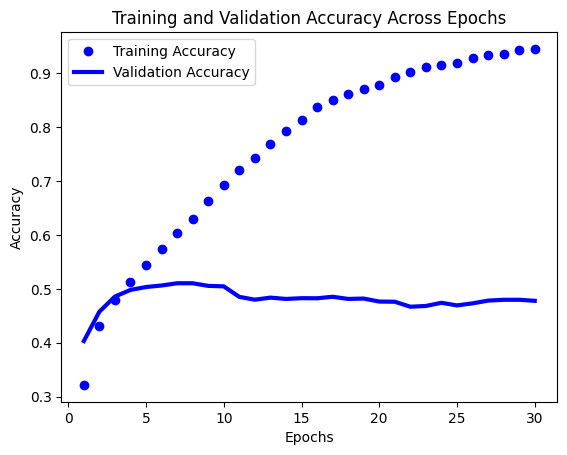

In [33]:
plot_accuracy(model_augmented_history)

In [34]:
model_augmented.evaluate(test_faces, test_emotions)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4813 - loss: 4.5224


[4.522420883178711, 0.48133185505867004]

Compare this with `wider_model` and comment on the impact of data augmentation.

* Did data augmentation reduce overfitting?
* Did data augmentation improve test set accuracy

<font color='red'> **Your Answer.** </font>

data_augmentation does not solve the problem of data overfitting,coz the train accuracy still reach the 100%, still overfitting occur. but the accuracy improve around 3% So finnaly come around 50.31% accuracy.

   # Problem 4: Transfer Learning and Fine-Tuning [25 points]

Next, we apply transfer learning to our problem using VGG19, a pre-trained model similar to ResNet50 from class. We will take VGG19 and make it "headless", then run it through our own "little" NN.

We will take three different approaches to this:

1. Part (a): **Base Transfer Learning**. Fix the weights from headless VGG19 and learn the weights on the little NN.
2. Part (b): **Some fine-tuning** Fix the weights on the top 6 out of 19 layers of VGG19, but allow the weights from the remaining 13 layers to be optimized by SGD/Adam, in addition to those of the little NN.
3. Part (c): **Fine-Tuning** Allow all weights in VGG19 to be tuned, in addition to the little NN.

For each of the models, we will plot their train/validation accuracy curve, compute their test accuracy, and compute a confusion matrix.

## Part (a): No Fine Tuning [5 Points]

Let us fetch the VGG19 model, making sure to set `include_top=False` so that we do not take its output layer. We also set `trainable=False` to indicate that the parameters in these 19 layers are not trainable.



In [35]:
base_model = keras.applications.VGG19(
    include_top=False,   # this makes VGG19 headless
    weights="imagenet",
    input_tensor=None,
    input_shape=(48, 48, 3),
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
)

# Freeze the base_model so that it is not trainable at all
base_model.trainable = False

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


We build a neural network that performs data augmentation and rescaling, then uses the VGG19, and finally has one dense layer before the output layer.

In [38]:
inputs = keras.Input(shape=(48,48,3))

x = keras.layers.RandomFlip("horizontal")(inputs)
x = keras.layers.RandomZoom(0.2)(x)
x = keras.layers.Rescaling(1./255)(x) # normalizing

# Add layers from base_model one at a time
x = base_model(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation='relu')(x)
outputs = keras.layers.Dense(7, activation='softmax')(x)

transfer_model = keras.Model(inputs, outputs, name='transfer_model')
transfer_model.summary()

Model: "transfer_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_21 (RandomFlip)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_21 (RandomZoom)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 1, 1, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,157,511 (76.89 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

Train the model. Here, we use a learning rate of 0.00002 to get better convergence.

In [39]:
transfer_model.compile(loss='categorical_crossentropy',
            optimizer=keras.optimizers.Adam(2e-5),
            metrics=['accuracy'])

transfer_model_history = transfer_model.fit(train_faces, train_emotions, epochs=30, validation_split=0.2)

Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.2391 - loss: 1.8612 - val_accuracy: 0.2910 - val_loss: 1.7548
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3023 - loss: 1.7319 - val_accuracy: 0.3285 - val_loss: 1.6958
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.3249 - loss: 1.6960 - val_accuracy: 0.3379 - val_loss: 1.6674
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3330 - loss: 1.6779 - val_accuracy: 0.3447 - val_loss: 1.6506
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3364 - loss: 1.6672 - val_accuracy: 0.3483 - val_loss: 1.6399
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3454 - loss: 1.6551 - val_accuracy: 0.3520 - val_loss: 1.6320
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3463 - loss: 1.6496 - val_accuracy: 0.3542 - val_loss: 1.6259
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3481 - loss: 1.6434 - 

We can plot the training and validation accuracy curve.

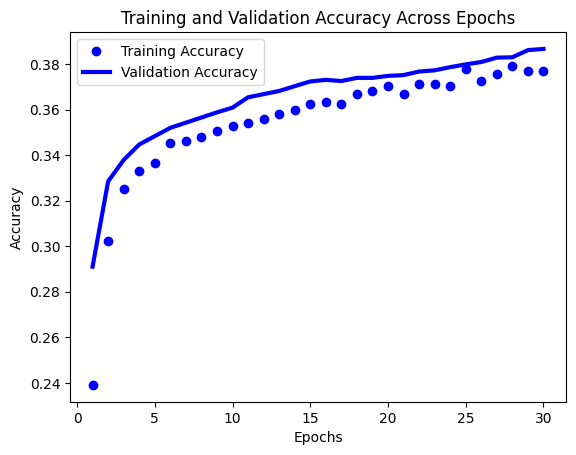

In [40]:
plot_accuracy(transfer_model_history)

Let's also calculate the confusion matrix and the accuracy on the test set.

The function `show_confusion_matrix` has been written for you below. You can apply it to any Keras Model and it will calculate:
* Test accuracy
* A confusion matrix. Recall that each row of the confusion matrix are the actual labels and each column are the predictions. For example, if element in row `happy` and column `sad` is 250, then there are 250 data points in the test set where the true label is `happy` but we predicted `sad`.
* A heatmap of the confusion matrix, where each row is normalized to add up to 1.0. For example, if element in row `happy` and column `sad` is 0.25, then that means 25% of data points with a true label of `happy` were predicted as `sad`.

225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step
*************************
* Test Accuracy: 0.3743 *
*************************


,angry,disgust,fear,happy,sad,surprise,neutral
angry,142,0,64,443,98,60,151
disgust,11,0,20,47,15,5,13
fear,65,0,135,395,134,147,148
happy,60,0,52,1332,111,48,171
sad,107,0,92,546,283,33,186
surprise,26,0,85,189,25,408,98
neutral,78,0,59,545,104,60,387


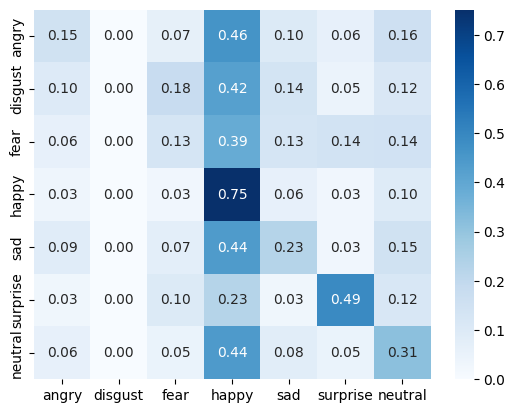

In [41]:
from IPython.display import display

def show_confusion_matrix(model):
    """
    Calculates the test accuracy, confusion matrix and heat map for a model.
    """
    global test_faces, test_emotions, emotions_names

    y_pred = model.predict(test_faces).argmax(axis=1)
    y_actual = test_emotions.argmax(axis=1)

    print('*************************\n* Test Accuracy: %.4f *\n*************************' % metrics.accuracy_score(y_actual, y_pred))

    cm = pd.DataFrame(metrics.confusion_matrix(y_actual, y_pred), index=emotions_names, columns=emotions_names)
    display(cm)

    cm = cm.div(cm.sum(axis=1), axis=0)

    sns.heatmap(cm, cmap="Blues", annot=True, fmt=".2f")

show_confusion_matrix(transfer_model)

Please comment briefly on the model's performance.

<font color='red'> **Your Answer** </font>

Model shows the accuracy of about 37%, which is very poor, Then it classify every image as happy, so there is overfitting.

## Part (b): Some Fine Tuning [5 Points]
In this part, we will allow our optimization model to tune **some** of the layers from VGG19. In particular, we will only freeze the first 15 layers and allow the remaining layers to be trained.


In [43]:
base_model = keras.applications.VGG19(
    include_top=False,   # this makes VGG19 headless
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
)

inputs = keras.Input(shape=(48,48,3))

x = keras.layers.RandomFlip("horizontal")(inputs)
x = keras.layers.RandomZoom(0.2)(x)
x = keras.layers.Rescaling(1./255)(x) # normalizing

# Add layers from base_model

x = base_model(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation='relu')(x)
outputs = keras.layers.Dense(7, activation='softmax')(x)

partial_model = keras.Model(inputs, outputs, name='partial_fine_tune_model')

# Make the first 15 layers not trainable. All other layers are trainable
for layer in partial_model.layers[:15]:
    layer.trainable = False

partial_model.summary()

Model: "partial_fine_tune_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_23 (RandomFlip)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_23 (RandomZoom)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_9 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 1, 1, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,157,511 (76.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,157,511 (76.89 MB)

Let's see which layers are trainable. Notice that VGG19 consists of 4 blocks of convolution filters (block1_conv1, block1_conv2, ..., block5_conv4). We are allowing block4 and block5 to be trained and freezing blocks 1, 2 and 3.

In [44]:
for i, layer in enumerate(partial_model.layers):
    print('Layer %d: %s (%s), Trainable=%s' % (i+1, layer.name, layer.__class__.__name__, layer.trainable))

Layer 1: input_layer_11 (InputLayer), Trainable=False
Layer 2: random_flip_23 (RandomFlip), Trainable=False
Layer 3: random_zoom_23 (RandomZoom), Trainable=False
Layer 4: rescaling_9 (Rescaling), Trainable=False
Layer 5: vgg19 (Functional), Trainable=False
Layer 6: flatten_6 (Flatten), Trainable=False
Layer 7: dense_4 (Dense), Trainable=False
Layer 8: dense_5 (Dense), Trainable=False


Train the model and examine its train/validation curve, test accuracy and confusion matrix.

In [45]:
partial_model.compile(loss='categorical_crossentropy',
            optimizer=keras.optimizers.Adam(2e-5),
            metrics=['accuracy'])

partial_model_history = partial_model.fit(train_faces, train_emotions, epochs=30, validation_split=0.2)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.1383 - loss: 2.0694 - val_accuracy: 0.1472 - val_loss: 2.0305
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.1368 - loss: 2.0687 - val_accuracy: 0.1472 - val_loss: 2.0305
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.1375 - loss: 2.0678 - val_accuracy: 0.1472 - val_loss: 2.0305
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.1381 - loss: 2.0685 - val_accuracy: 0.1472 - val_loss: 2.0305
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.1389 - loss: 2.0687 - val_accuracy: 0.1472 - val_loss: 2.0305
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.1389 - loss: 2.0674 - val_accuracy: 0.1472 - val_loss: 2.0305
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.1369 - loss: 2.0695 - val_accuracy: 0.1472 - val_loss: 2.0305
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.1365 - loss: 2.0693 - val_accurac

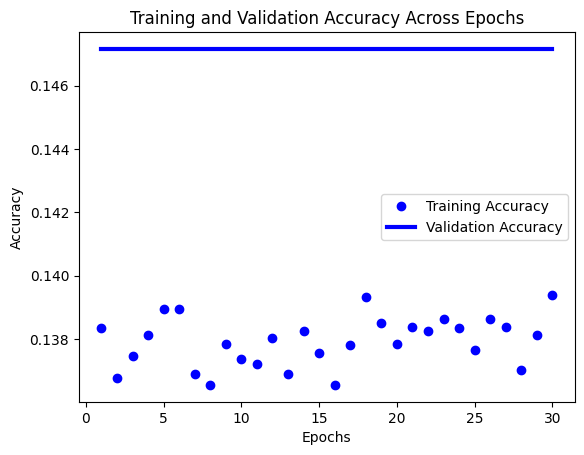

In [46]:
plot_accuracy(partial_model_history)

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step
*************************
* Test Accuracy: 0.1335 *
*************************


,angry,disgust,fear,happy,sad,surprise,neutral
angry,845,5,0,7,65,24,12
disgust,108,0,0,0,2,1,0
fear,882,8,0,9,72,40,13
happy,1585,7,0,16,95,48,23
sad,1128,3,0,8,59,33,16
surprise,657,9,0,18,115,16,16
neutral,1085,5,0,27,63,31,22


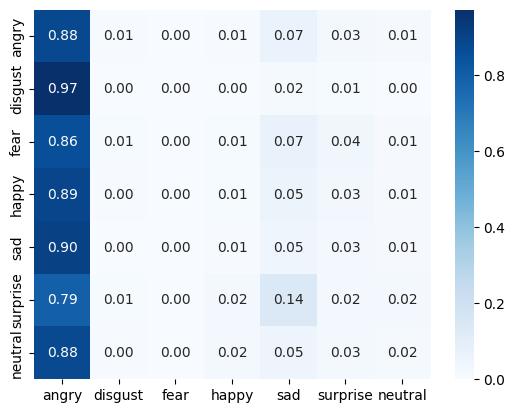

In [47]:
show_confusion_matrix(partial_model)

Please comment briefly on the model's performance.  

<font color='red'> **Your Answer** </font>

The accuracy is low and still overfitting take place in the model.

## Part (c): Fine Tuning [5 Points]
Now, let's try a transfer learning model where all layers can be fine tuned.

In [48]:
base_model = keras.applications.VGG19(
    include_top=False,   # this makes VGG19 headless
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
)

inputs = keras.Input(shape=(48,48,3))

x = keras.layers.RandomFlip("horizontal")(inputs)
x = keras.layers.RandomZoom(0.2)(x)
x = keras.layers.Rescaling(1./255)(x) # normalizing

# Add layers from base_model
x = base_model(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation='relu')(x)
outputs = keras.layers.Dense(7, activation='softmax')(x)

tuned_model = keras.Model(inputs, outputs, name='full_fine_tune_model')

# Let's see which layers are trainable
for i, layer in enumerate(tuned_model.layers):
    print('Layer %d: %s (%s), Trainable=%s' % (i+1, layer.name, layer.__class__.__name__, layer.trainable))

Layer 1: input_layer_13 (InputLayer), Trainable=True
Layer 2: random_flip_24 (RandomFlip), Trainable=True
Layer 3: random_zoom_24 (RandomZoom), Trainable=True
Layer 4: rescaling_10 (Rescaling), Trainable=True
Layer 5: vgg19 (Functional), Trainable=True
Layer 6: flatten_7 (Flatten), Trainable=True
Layer 7: dense_6 (Dense), Trainable=True
Layer 8: dense_7 (Dense), Trainable=True


In [49]:
tuned_model.compile(loss='categorical_crossentropy',
            optimizer=keras.optimizers.Adam(2e-5),
            metrics=['accuracy'])

tuned_model_history = tuned_model.fit(train_faces, train_emotions, epochs=30, validation_split=0.2)

Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 52s 65ms/step - accuracy: 0.4403 - loss: 1.4434 - val_accuracy: 0.5265 - val_loss: 1.2621
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 46s 64ms/step - accuracy: 0.5412 - loss: 1.2074 - val_accuracy: 0.5479 - val_loss: 1.2038
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.5731 - loss: 1.1213 - val_accuracy: 0.5798 - val_loss: 1.1171
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.6070 - loss: 1.0509 - val_accuracy: 0.5930 - val_loss: 1.0852
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.6266 - loss: 0.9917 - val_accuracy: 0.5970 - val_loss: 1.0847
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.6481 - loss: 0.9348 - val_accuracy: 0.6071 - val_loss: 1.0784
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.6729 - loss: 0.8762 - val_accuracy: 0.6116 - val_loss: 1.1009
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.6961 - loss: 0.8212 - 

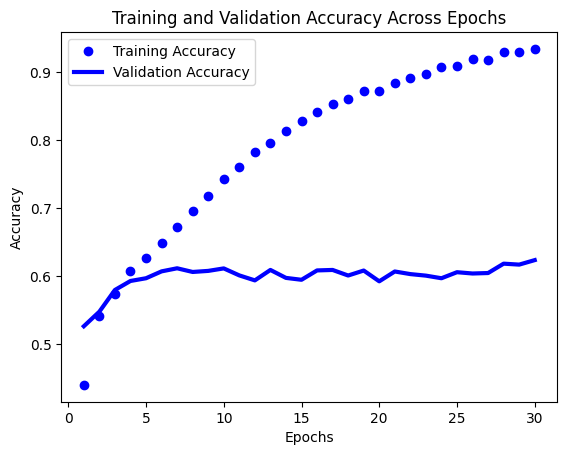

In [50]:
plot_accuracy(tuned_model_history)

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step
*************************
* Test Accuracy: 0.6204 *
*************************


,angry,disgust,fear,happy,sad,surprise,neutral
angry,510,11,94,50,171,27,95
disgust,32,50,7,3,12,1,6
fear,122,2,424,48,218,99,111
happy,39,0,28,1477,75,62,93
sad,165,6,134,57,669,30,186
surprise,33,3,64,41,36,635,19
neutral,91,2,69,122,221,40,688


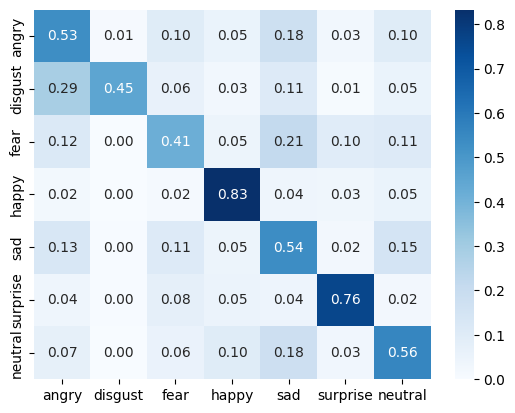

In [51]:
show_confusion_matrix(tuned_model)

Please comment briefly on the model's performance.  

<font color='red'> **Your Answer** </font>

The model has a good accuracy of around 94% when every layer in the model changes.

## Part (d): Comparison [10 Points]

Please fill in the table below with the test accuracies of the three models above, as well as that of `wider_model` from Problem 2.

<font color='red'>**Your Answer.**</font>

Model Test Accuracy:
* Model (a) with no fine tuning: 37.69%
* Model (b) with some fine tuning: 13.94%
* Model (c) with fine tuning: 93.39%
* `wider_model` from Problem 2(a)-(c): 0.00%


Comment on the performance of Models (a), (b) and (c). In particular, please address the following questions:

* Why do models (b) and (c) perform so much better than `wider_model`?
* Why do you think Model (a) performs so poorly?
* Why do you think Model (c) performs better than model (b)?

<font color='red'>**Your Answer.**</font>

_Please replace this text with your answer_

# Task
Correctly integrate `base_model` into the `transfer_model` by replacing the loop iterating through `base_model.layers` with a single call to `base_model(x)`.

## Correctly integrate base_model

### Subtask:
Replace the loop iterating through `base_model.layers` with a single call to `base_model(x)` to properly pass the tensor through the pre-trained VGG19 model.


## Summary:

### Data Analysis Key Findings
No data analysis was performed in this step. The task involved a code modification to correctly integrate a pre-trained model.

### Insights or Next Steps
*   The next step will be to implement the described code change, replacing the layer-by-layer iteration with a direct call to `base_model(x)`.
